In [43]:
import sys, importlib, os, inspect
import pandas as pd
import numpy as np
from collections import defaultdict
from pathlib import Path

# === PATHS (your versions) ===
NEW_ROOT = "/blue/npadillacoreano/sequioasmith/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory"
os.chdir("/blue/npadillacoreano/sequioasmith/rehouse_code/diff_fam_social_memory_ephys")

# === IMPORT MODULES ===
import behavior.boris_extraction as boris
import lfp.lfp_analysis.LFP_collection as LFP_collection
import trodes.read_exported as tr

# === VERIFY IMPORTS ===
print("behavior package from:", boris.__file__)
print("boris_extraction from:", inspect.getfile(boris))
print("trodes read_exported from:", inspect.getfile(tr))

# === DATA PATHS ===
rec_root = Path("/blue/npadillacoreano/share/rehouse_data/data_rehouse/lfp_subset")
time_root = Path("/blue/npadillacoreano/share/rehouse_data/data_rehouse")

print("\nData paths:")
print("rec_root exists:", rec_root.exists(), "|", rec_root)
print("time_root exists:", time_root.exists(), "|", time_root)

behavior package from: /blue/npadillacoreano/sequioasmith/rehouse_code/diff_fam_social_memory_ephys/behavior/boris_extraction.py
boris_extraction from: /blue/npadillacoreano/sequioasmith/rehouse_code/diff_fam_social_memory_ephys/behavior/boris_extraction.py
trodes read_exported from: /blue/npadillacoreano/sequioasmith/rehouse_code/diff_fam_social_memory_ephys/trodes/read_exported.py

Data paths:
rec_root exists: True | /blue/npadillacoreano/share/rehouse_data/data_rehouse/lfp_subset
time_root exists: True | /blue/npadillacoreano/share/rehouse_data/data_rehouse


In [44]:
!ls /blue/npadillacoreano/share/rehouse_data/data_rehouse/lfp_subset


22_23_rehouse_d0.rec  31_32_rehouse_d7.rec  Untitled.ipynb
22_23_rehouse_d7.rec  41_44_rehouse_d0.rec
31_32_rehouse_d0.rec  41_44_rehouse_d7.rec


In [45]:
pd.set_option('display.max_colwidth', 0)  # 0 means unlimited in newer pandas versions

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Don’t truncate column contents
pd.set_option("display.max_colwidth", None)

# Expand the display to the full width of the screen
pd.set_option("display.width", 0)


### Mapping Merged LFP Files to Video Timestamp Files

This dictionary (`merge_to_video`) defines how each subject’s **merged LFP time file** aligns with the correct **video timestamp file** for synchronization.

Each pair of subjects (e.g., `41` & `44`) shares one behavioral video with two sets of timestamps (`.1` and `.2`).  
This mapping tells the pipeline which `.videoTimeStamps` file corresponds to which subject’s LFP data.

####  Example
```python
"41_rehouse_d0_merged.time" → "41_44_rehouse_d0.2.videoTimeStamps"
"44_rehouse_d0_merged.time" → "41_44_rehouse_d0.1.videoTimeStamps"


In [46]:
merge_to_video = {
    "22_rehouse_d0_merged.time": "22_23_rehouse_d0.2.videoTimeStamps",
    "23_rehouse_d0_merged.time": "22_23_rehouse_d0.1.videoTimeStamps",
    "22_rehouse_d1_merged.time": "22_23_rehouse_d1.1.videoTimeStamps",
    "23_rehouse_d1_merged.time": "22_23_rehouse_d1.2.videoTimeStamps",
    "22_rehouse_d3_merged.time": "22_23_rehouse_d3.2.videoTimeStamps",
    "23_rehouse_d3_merged.time": "22_23_rehouse_d3.1.videoTimeStamps",
    "22_rehouse_d4_merged.time": "22_23_rehouse_d4.2.videoTimeStamps",
    "23_rehouse_d4_merged.time": "22_23_rehouse_d4.1.videoTimeStamps",
    "22_rehouse_d5_merged.time": "22_23_rehouse_d5.2.videoTimeStamps",
    "23_rehouse_d5_merged.time": "22_23_rehouse_d5.1.videoTimeStamps",
    "22_rehouse_d6_merged.time": "22_23_rehouse_d6.2.videoTimeStamps",
    "23_rehouse_d6_merged.time": "22_23_rehouse_d6.1.videoTimeStamps",
    "22_rehouse_d7_merged.time": "22_23_rehouse_d7.2.videoTimeStamps",
    "23_rehouse_d7_merged.time": "22_23_rehouse_d7.1.videoTimeStamps",
    "31_rehouse_d0_merged.time": "31_32_rehouse_d0.1.videoTimeStamps",
    "32_rehouse_d0_merged.time": "31_32_rehouse_d0.2.videoTimeStamps",
    "31_rehouse_d1_merged.time": "31_32_rehouse_d1.2.videoTimeStamps",
    "32_rehouse_d1_merged.time": "31_32_rehouse_d1.1.videoTimeStamps",
    "31_rehouse_d2_merged.time": "31_32_rehouse_d2.2.videoTimeStamps",
    "32_rehouse_d2_merged.time": "31_32_rehouse_d2.1.videoTimeStamps",
    "31_rehouse_d3_merged.time": "31_32_rehouse_d3.2.videoTimeStamps",
    "32_rehouse_d3_merged.time": "31_32_rehouse_d3.1.videoTimeStamps",
    "31_rehouse_d4_merged.time": "31_32_rehouse_d4.2.videoTimeStamps",
    "32_rehouse_d4_merged.time": "31_32_rehouse_d4.1.videoTimeStamps",
    "31_rehouse_d5_merged.time": "31_32_rehouse_d5.2.videoTimeStamps",
    "32_rehouse_d5_merged.time": "31_32_rehouse_d5.1.videoTimeStamps",
    "31_rehouse_d6_merged.time": "31_32_rehouse_d6.2.videoTimeStamps",
    "32_rehouse_d6_merged.time": "31_32_rehouse_d6.1.videoTimeStamps",
    "31_rehouse_d7_merged.time": "31_32_rehouse_d7.2.videoTimeStamps",
    "32_rehouse_d7_merged.time": "31_32_rehouse_d7.1.videoTimeStamps",
    "41_rehouse_d0_merged.time": "41_44_rehouse_d0.2.videoTimeStamps",
    "44_rehouse_d0_merged.time": "41_44_rehouse_d0.1.videoTimeStamps",
    "41_rehouse_d1_merged.time": "41_44_rehouse_d1.2.videoTimeStamps",
    "44_rehouse_d1_merged.time": "41_44_rehouse_d1.1.videoTimeStamps",
    "41_rehouse_d2_merged.time": "41_44_rehouse_d2.2.videoTimeStamps",
    "44_rehouse_d2_merged.time": "41_44_rehouse_d2.1.videoTimeStamps",
    "41_rehouse_d3_merged.time": "41_44_rehouse_d3.1.videoTimeStamps",
    "44_rehouse_d3_merged.time": "41_44_rehouse_d3.2.videoTimeStamps",
    "41_rehouse_d4_merged.time": "41_44_rehouse_d4.2.videoTimeStamps",
    "44_rehouse_d4_merged.time": "41_44_rehouse_d4.1.videoTimeStamps",
    "41_rehouse_d5_merged.time": "41_44_rehouse_d5.2.videoTimeStamps",
    "44_rehouse_d5_merged.time": "41_44_rehouse_d5.1.videoTimeStamps",
    "41_rehouse_d6_merged.time": "41_44_rehouse_d6.2.videoTimeStamps",
    "44_rehouse_d6_merged.time": "41_44_rehouse_d6.1.videoTimeStamps",
    "41_rehouse_d7_merged.time": "41_44_rehouse_d7.2.videoTimeStamps",
    "44_rehouse_d7_merged.time": "41_44_rehouse_d7.1.videoTimeStamps"
}

### Mapping `.rec` recordings to their corresponding `.time` alignment files

The `rec_to_timefile` dictionary connects each merged `.rec` recording file to its
matching `.time` file for time alignment during LFP preprocessing.  
Only Day 0 and Day 7 recordings are included for each subject.


In [47]:
rec_to_timefile = {
    "22_rehouse_d0_merged.rec": "22_rehouse_d0_merged.time",
    "22_rehouse_d7_merged.rec": "22_rehouse_d7_merged.time",
    "23_rehouse_d0_merged.rec": "23_rehouse_d0_merged.time",
    "23_rehouse_d7_merged.rec": "23_rehouse_d7_merged.time",
    "31_rehouse_d0_merged.rec": "31_rehouse_d0_merged.time",
    "31_rehouse_d7_merged.rec": "31_rehouse_d7_merged.time",
    "32_rehouse_d0_merged.rec": "32_rehouse_d0_merged.time",
    "32_rehouse_d7_merged.rec": "32_rehouse_d7_merged.time",
    "41_rehouse_d0_merged.rec": "41_rehouse_d0_merged.time",
    "41_rehouse_d7_merged.rec": "41_rehouse_d7_merged.time",
    "44_rehouse_d0_merged.rec": "44_rehouse_d0_merged.time",
    "44_rehouse_d7_merged.rec": "44_rehouse_d7_merged.time",
}


### Define behavior CSV paths for Day 0 and Day 7 sessions
Each variable below points to the aggregated behavioral CSV corresponding to
the given subject and day. The files are stored in:
`/blue/npadillacoreano/share/rehouse_data/behavior_csvs/aggregated_csvs/`


In [48]:
!ls /blue/npadillacoreano/share/rehouse_data/behavior_csvs/aggregated_csvs


22_rehouse_d0_OM.csv  31_rehouse_d0_OM.csv  41_rehouse_d0_OM.csv
22_rehouse_d1_MO.csv  31_rehouse_d1_MO.csv  41_rehouse_d1_MO.csv
22_rehouse_d2_OM.csv  31_rehouse_d2_MO.csv  41_rehouse_d2_OM.csv
22_rehouse_d3_MO.csv  31_rehouse_d2_OM.csv  41_rehouse_d3_OM.csv
22_rehouse_d4_OM.csv  31_rehouse_d3_MO.csv  41_rehouse_d4_OM.csv
22_rehouse_d5_MO.csv  31_rehouse_d4_OM.csv  41_rehouse_d5_MO.csv
22_rehouse_d6_OM.csv  31_rehouse_d5_MO.csv  41_rehouse_d6_OM.csv
22_rehouse_d7_MO.csv  31_rehouse_d6_OM.csv  41_rehouse_d7_MO.csv
23_rehouse_d0_MO.csv  31_rehouse_d7_MO.csv  44_rehouse_d0_MO.csv
23_rehouse_d1_OM.csv  32_rehouse_d0_MO.csv  44_rehouse_d1_OM.csv
23_rehouse_d2_MO.csv  32_rehouse_d1_OM.csv  44_rehouse_d2_MO.csv
23_rehouse_d3_OM.csv  32_rehouse_d3_OM.csv  44_rehouse_d3_OM.csv
23_rehouse_d4_MO.csv  32_rehouse_d4_MO.csv  44_rehouse_d5_OM.csv
23_rehouse_d5_OM.csv  32_rehouse_d5_OM.csv  44_rehouse_d6_MO.csv
23_rehouse_d6_MO.csv  32_rehouse_d6_MO.csv  44_rehouse_d7_OM.csv
23_rehouse_d7_OM.csv  32_

### Define behavior CSV paths (Day 0 and Day 7 for all subjects)
Each variable below specifies the full path to the aggregated behavioral CSV
for the corresponding subject and recording day.  

All files are stored in the shared lab directory:
`/blue/npadillacoreano/share/rehouse_data/behavior_csvs/aggregated_csvs/`
This makes the notebook portable for any lab member using the shared environment.


In [49]:
base_beh_path = "/blue/npadillacoreano/share/rehouse_data/behavior_csvs/aggregated_csvs"

d0_22_beh_path = f"{base_beh_path}/22_rehouse_d0_OM.csv"
d7_22_beh_path = f"{base_beh_path}/22_rehouse_d7_MO.csv"
d0_23_beh_path = f"{base_beh_path}/23_rehouse_d0_MO.csv"
d7_23_beh_path = f"{base_beh_path}/23_rehouse_d7_OM.csv"
d0_31_beh_path = f"{base_beh_path}/31_rehouse_d0_OM.csv"
d7_31_beh_path = f"{base_beh_path}/31_rehouse_d7_MO.csv"
d0_32_beh_path = f"{base_beh_path}/32_rehouse_d0_MO.csv"
d7_32_beh_path = f"{base_beh_path}/32_rehouse_d7_OM.csv"
d0_41_beh_path = f"{base_beh_path}/41_rehouse_d0_OM.csv"
d7_41_beh_path = f"{base_beh_path}/41_rehouse_d7_MO.csv"
d0_44_beh_path = f"{base_beh_path}/44_rehouse_d0_MO.csv"
d7_44_beh_path = f"{base_beh_path}/44_rehouse_d7_OM.csv"


### Define data_path for raw LFP recordings

This variable points to the shared lab folder containing all raw `.rec` LFP
recordings used for collection creation.  
Keeping this variable makes the notebook portable across users and projects.


In [50]:
# Shared folder containing all raw .rec LFP files
data_path = "/blue/npadillacoreano/share/rehouse_data/raw_lfp_data"

print("Data path set to:", data_path)


Data path set to: /blue/npadillacoreano/share/rehouse_data/raw_lfp_data


### Load and filter behavioral data for all subjects (Day 0 and Day 7)

Each CSV is loaded into a DataFrame using `pandas.read_csv()`.  
We then filter the data to include only rows where `"Subject" == 'subject'`, which corresponds
to the main experimental animal (not the social partner).  

This prepares subject-specific behavioral data for later alignment with LFP recordings.


In [51]:
import pandas as pd

# --- Subject 22 ---
d0_22_beh = pd.read_csv(d0_22_beh_path)
d0_22_subj_beh = d0_22_beh[d0_22_beh['Subject'] == 'subject']

d7_22_beh = pd.read_csv(d7_22_beh_path)
d7_22_subj_beh = d7_22_beh[d7_22_beh['Subject'] == 'subject']

# --- Subject 23 ---
d0_23_beh = pd.read_csv(d0_23_beh_path)
d0_23_subj_beh = d0_23_beh[d0_23_beh['Subject'] == 'subject']

d7_23_beh = pd.read_csv(d7_23_beh_path)
d7_23_subj_beh = d7_23_beh[d7_23_beh['Subject'] == 'subject']

# --- Subject 31 ---
d0_31_beh = pd.read_csv(d0_31_beh_path)
d0_31_subj_beh = d0_31_beh[d0_31_beh['Subject'] == 'subject']

d7_31_beh = pd.read_csv(d7_31_beh_path)
d7_31_subj_beh = d7_31_beh[d7_31_beh['Subject'] == 'subject']

# --- Subject 32 ---
d0_32_beh = pd.read_csv(d0_32_beh_path)
d0_32_subj_beh = d0_32_beh[d0_32_beh['Subject'] == 'subject']

d7_32_beh = pd.read_csv(d7_32_beh_path)
d7_32_subj_beh = d7_32_beh[d7_32_beh['Subject'] == 'subject']

# --- Subject 41 ---
d0_41_beh = pd.read_csv(d0_41_beh_path)
d0_41_subj_beh = d0_41_beh[d0_41_beh['Subject'] == 'subject']

d7_41_beh = pd.read_csv(d7_41_beh_path)
d7_41_subj_beh = d7_41_beh[d7_41_beh['Subject'] == 'subject']

# --- Subject 44 ---
d0_44_beh = pd.read_csv(d0_44_beh_path)
d0_44_subj_beh = d0_44_beh[d0_44_beh['Subject'] == 'subject']

d7_44_beh = pd.read_csv(d7_44_beh_path)
d7_44_subj_beh = d7_44_beh[d7_44_beh['Subject'] == 'subject']

# --- Preview one example ---
d0_31_subj_beh.head()


,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop
1,31_d0,2025-03-27 21:44:31.975,NaN,Media file,player #1:31_rehouse_d0_converted.mp4,0.0,1199.8,1801.067,15.0,subject,289.319,sniffing object,Not defined,STATE,606.067,615.467,9.400,31_rehouse_d0_converted.mp4,9091.0,9232.0,NaN,NaN,NaN,NaN
2,31_d0,2025-03-27 21:44:31.975,NaN,Media file,player #1:31_rehouse_d0_converted.mp4,0.0,1199.8,1801.067,15.0,subject,289.319,sniffing object,Not defined,STATE,617.400,619.733,2.333,31_rehouse_d0_converted.mp4,9261.0,9296.0,NaN,NaN,NaN,NaN
3,31_d0,2025-03-27 21:44:31.975,NaN,Media file,player #1:31_rehouse_d0_converted.mp4,0.0,1199.8,1801.067,15.0,subject,289.319,sniffing object,Not defined,STATE,621.800,624.133,2.333,31_rehouse_d0_converted.mp4,9327.0,9362.0,NaN,NaN,NaN,NaN
4,31_d0,2025-03-27 21:44:31.975,NaN,Media file,player #1:31_rehouse_d0_converted.mp4,0.0,1199.8,1801.067,15.0,subject,289.319,sniffing object,Not defined,STATE,628.200,630.467,2.267,31_rehouse_d0_converted.mp4,9423.0,9457.0,NaN,NaN,NaN,NaN
5,31_d0,2025-03-27 21:44:31.975,NaN,Media file,player #1:31_rehouse_d0_converted.mp4,0.0,1199.8,1801.067,15.0,subject,289.319,sniffing object,Not defined,STATE,630.933,632.733,1.800,31_rehouse_d0_converted.mp4,9464.0,9491.0,NaN,NaN,NaN,NaN


In [52]:
# Optional check (for debugging only)
# print(d0_41_beh.columns)
# print(d0_41_beh['Behavior'].unique())


In [53]:
d0_41_beh.columns

Index(['Observation id', 'Observation date', 'Description', 'Observation type',
       'Source', 'Time offset (s)', 'Coding duration', 'Media duration (s)',
       'FPS (frame/s)', 'Subject',
       'Observation duration by subject by observation', 'Behavior',
       'Behavioral category', 'Behavior type', 'Start (s)', 'Stop (s)',
       'Duration (s)', 'Media file name', 'Image index start',
       'Image index stop', 'Image file path start', 'Image file path stop',
       'Comment start', 'Comment stop'],
      dtype='object')

In [54]:
list(d0_41_beh['Behavior'].unique())

['mice back in',
 'sniffing object',
 'mice taken out',
 'facial sniffing',
 'anogenital sniffing']

### Aligning BORIS behavioral data to neural recordings

This section extracts the first Trodes timestamp from each `.time` folder to
align behavioral events with electrophysiology recordings.  
Each entry in the resulting dictionary maps a `.time` folder name to its
corresponding `first_timestamp` (in Trodes clock units).  
This alignment is later used to synchronize BORIS behaviors with neural data.


### Function: `build_first_ts_dict(data_path)`

This helper function walks through every `.time` folder inside the provided 
`data_path` (the raw LFP data directory). For each folder, it locates the 
`.dat` file exported from Trodes (e.g., `videoTimeStamps.dat`) and extracts the 
first timestamp recorded by the acquisition system.

It then builds and returns a dictionary that maps each `.time` folder name 
(e.g., `41_rehouse_d0_merged.time`) to its corresponding `first_timestamp` 
value (in Trodes clock units). 

This dictionary provides the alignment reference between the neural data 
(recording start time) and behavioral/video timestamps used later for 
synchronization.


In [55]:
first_timestamp_dict = {}

# Step 1: extract first_timestamp from all *.dat file
def build_first_ts_dict(data_path):
    for dirpath, dirnames, filenames in os.walk(data_path):
        if os.path.basename(dirpath).endswith('.time'):
            for file in filenames:
                if file.endswith(".dat"):
                    ts_file = os.path.join(dirpath, file)
                    ts_dict = tr.read_trodes_extracted_data_file(ts_file)
                    first_timestamp = ts_dict['first_timestamp']

                    # key is .time folder name
                    time_folder_name = os.path.basename(dirpath)
                    first_timestamp_dict[time_folder_name] = int(first_timestamp)
                
    return first_timestamp_dict # dict[.time folder] = int(.dat first timestamp or where play starts)


### Function: `build_play_indexed_ts_dict(data_path, first_timestamp_dict)`

This helper function constructs `play_indexed_dict`, which stores video 
timestamps aligned to each recording's playback (Trodes) time base.

**What it does:**
1. Walks through every `.rec` directory in `data_path` (the raw LFP data folder).
2. For each `.rec` folder, it looks for a matching `.time` folder listed in 
   `first_timestamp_dict`.
3. Uses the `merge_to_video` mapping to locate the corresponding 
   `.videoTimeStamps` file.
4. Reads the video timestamps using  
   `tr.readCameraModuleTimeStamps(videotsfile)`.
5. Subtracts the recording's first Trodes timestamp (converted to seconds)  
   to align the video timestamps with neural recording time.
6. Creates a dictionary entry for each session with:
   - `play_indexed_array`: timestamps aligned to playback start  
   - `stream_indexed_array`: raw video timestamps  
   - `first_timestamp`: the raw first Trodes timestamp

**Output:**
`play_indexed_dict` — a dictionary mapping each `.videoTimeStamps` file name  
to its aligned timestamp arrays.  
This alignment step is critical for synchronizing video-based behavioral 
data (from BORIS) with neural recordings in the next stage.


In [56]:
# Step 2: build play_indexed_dict from each .videoTimeStamps, which holds a play indexed videotimestamped array
play_indexed_dict = {}

def build_play_indexed_ts_dict(data_path, first_timestamp_dict):
    # data_path = /home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/raw_lfp_data
    for dirpath, dirnames, filenames in os.walk(data_path):
        
        # Check if current directory name ends with ".rec"
        if os.path.basename(dirpath).endswith(".rec"): 
            
            # directly accessing .videotimestamps using the mapping
            for time_folder in first_timestamp_dict.keys():
                if time_folder in dirnames:
                    
                    if time_folder not in merge_to_video:
                        print(f"no mapping for {time_folder}")
                        continue
                        
                    videotsfile = os.path.join(dirpath, merge_to_video[time_folder])
                    if not os.path.exists(videotsfile):
                        print(f"videotimestamps file does not exist or mapping incorrect: {videotsfile}\n")
                        continue
                    
                    videotsarray = tr.readCameraModuleTimeStamps(videotsfile)
                    first_ts = first_timestamp_dict[time_folder]
                    
                    videotsarray_play_indexed = videotsarray - first_ts/20000
                    if videotsarray_play_indexed[0] < 0:
                        if abs(videotsarray_play_indexed[0]) < .001:
                            videotsarray_play_indexed[0] = 0
                        else:
                            print(f'negative first timestamp: {videotsarray_play_indexed[0]} in {merge_to_video[time_folder]}')

                    play_indexed_dict[merge_to_video[time_folder]] = {
                        'play_indexed_array': videotsarray_play_indexed,
                        'stream_indexed_array': videotsarray,
                        'first_timestamp': first_ts,
                    }
    
    return play_indexed_dict


### Building dicts with videotimestamp array and first timestamp from .dat
### Build `dat_first_timestamps` dictionary

This step runs the previously defined function `build_first_ts_dict(data_path)`
to extract the first timestamp from each `.dat` file in the `.time` folders
within `data_path`.  

The resulting dictionary (`dat_first_timestamps`) maps each `.time` folder name
(e.g., `41_rehouse_d0_merged.time`) to its first Trodes timestamp.  
This dictionary will be used to align neural recordings with video and
behavioral timestamps in subsequent steps.


In [57]:
# first .dat timestamp for each subject 
dat_first_timestamps = build_first_ts_dict(data_path)

### Sanity Checks for Timestamp Alignment

These quick checks confirm that:
- `.time` folders were read correctly and contain valid first timestamps.  
- `.videoTimeStamps` files were successfully aligned to the neural recordings.  
- The first aligned frame starts near 0 seconds.  
- Behavioral CSVs include frame and FPS columns needed for synchronization.


In [58]:
print(list(dat_first_timestamps.items())[:5]) # print first 5 key,value

[('44_rehouse_d3_merged.time', 1972093), ('41_rehouse_d3_merged.time', 1972093), ('31_rehouse_d0_merged.time', 2490408), ('32_rehouse_d0_merged.time', 2490408), ('41_rehouse_d6_merged.time', 2053859)]


In [59]:
# dict with .videotimestamps array and first timestamp of .videotimestamps
timestamps_dict = build_play_indexed_ts_dict(data_path, dat_first_timestamps)

no mapping for 22_rehouse_d2_merged.time
no mapping for 23_rehouse_d2_merged.time


In [60]:
print("Number of sessions with aligned video timestamps:", len(timestamps_dict))
list(timestamps_dict.keys())[:5]


Number of sessions with aligned video timestamps: 46


['41_44_rehouse_d3.2.videoTimeStamps',
 '41_44_rehouse_d3.1.videoTimeStamps',
 '31_32_rehouse_d0.1.videoTimeStamps',
 '31_32_rehouse_d0.2.videoTimeStamps',
 '41_44_rehouse_d6.2.videoTimeStamps']

In [61]:
print(list(timestamps_dict.items())[:3])

[('41_44_rehouse_d3.2.videoTimeStamps', {'play_indexed_array': array([0.00000000e+00, 6.92000000e-02, 1.38500000e-01, ...,
       1.80454065e+03, 1.80460995e+03, 1.80467925e+03], shape=(27071,)), 'stream_indexed_array': array([  98.60455,   98.67385,   98.74315, ..., 1903.1453 , 1903.2146 ,
       1903.2839 ], shape=(27071,)), 'first_timestamp': 1972093}), ('41_44_rehouse_d3.1.videoTimeStamps', {'play_indexed_array': array([0.00000000e+00, 6.92000000e-02, 1.38500000e-01, ...,
       1.80454065e+03, 1.80460995e+03, 1.80467925e+03], shape=(27071,)), 'stream_indexed_array': array([  98.60455,   98.67385,   98.74315, ..., 1903.1453 , 1903.2146 ,
       1903.2839 ], shape=(27071,)), 'first_timestamp': 1972093}), ('31_32_rehouse_d0.1.videoTimeStamps', {'play_indexed_array': array([6.9200000e-02, 1.4185000e-01, 2.0780000e-01, ..., 1.8010067e+03,
       1.8010760e+03, 1.8011453e+03], shape=(27016,)), 'stream_indexed_array': array([ 124.5896 ,  124.66225,  124.7282 , ..., 1925.5271 , 1925.5964 

In [62]:
for key, val in list(timestamps_dict.items())[:3]:
    print(f"{key}: first play_indexed_array = {val['play_indexed_array'][0]:.6f}")


41_44_rehouse_d3.2.videoTimeStamps: first play_indexed_array = 0.000000
41_44_rehouse_d3.1.videoTimeStamps: first play_indexed_array = 0.000000
31_32_rehouse_d0.1.videoTimeStamps: first play_indexed_array = 0.069200


In [63]:
print(list(timestamps_dict.keys())[:5]) # 5 keys to see what timestamps_dict keys looks like

['41_44_rehouse_d3.2.videoTimeStamps', '41_44_rehouse_d3.1.videoTimeStamps', '31_32_rehouse_d0.1.videoTimeStamps', '31_32_rehouse_d0.2.videoTimeStamps', '41_44_rehouse_d6.2.videoTimeStamps']


In [64]:
# simple helpers for getting Frames or FPS
def _has_frame_cols(df):
    return "Image index start" in df.columns

def _has_fps(df):
    return any("FPS" in c for c in df.columns)

### Building behavior dict function | takes both mac and windows scored boris 

### Handling Mac vs Windows BORIS Files

BORIS exports differ across operating systems.  
Windows-scored files include frame-based columns ("Image index start", "Image index stop"),
while Mac-scored files include frame rate information ("FPS").  

To ensure correct alignment with video timestamps, the extraction function automatically
detects the file type and selects the appropriate processing path:

- **Windows-scored files** use `get_behavior_bouts_frame()`, mapping frame indices directly
  to camera timestamps. Rows with missing frame indices are dropped to prevent index errors.
- **Mac-scored files** use `get_behavior_bouts_fps()`, converting start/stop times (s)
  to frame indices using the FPS value.
- If neither is available, `get_behavior_bouts()` is used as a fallback relying only on
  time values (not recommended for neural alignment).


In [65]:
def extract_bouts_for_recording(rec_time_file, boris_df, subject, behaviors):
    """
    Given a merged .time filename and its boris dataframe, returns bout array based on availability of frames. 
    Frames map to cameratimestamps, ex: 3rd frame maps to 3rd timestamp. So if we have frames we call function that
    finds the timestamps using frames for the behavioral bouts. Otherwise if there's fps we use it to convert stop start
    times in seconds to frames, then find the cameratimestamps for the bouts.
    
    Returns dict with behaviors start stop times in ms.
    
    rec_time_file: merged.time filename, used to find the corresponding .videotimestamps
    boris_df: dataframe of boris we're extracting behaviors from
    subject: list of subjects we're finding behaviors for, should be ['subject']
    behaviors: list of behaviors/events we want from the subject, will be the keys in our final event dict 
    """
    df_name = boris_df["Observation id"].unique()
    print(f"extracting for {df_name}")
    
    # Locating corresponding .videotimestamps of merged.time folder, in other words corresponding subject camera instance
    videotimestamps_filename = merge_to_video[rec_time_file]
    cameratimestamps = timestamps_dict[videotimestamps_filename]['stream_indexed_array'] # stream indexed or unaligned camera timestamps
    
    first_timestamp = dat_first_timestamps[rec_time_file] # .dat first timestamp

    
    def _extract_one_behavior(beh):
        if _has_frame_cols(boris_df):  # non-MAC scored (frame columns present)
            return boris.get_behavior_bouts_frame(
                boris_df=boris_df,
                cameratimestamps=cameratimestamps, # expects .videotimestamps array, not aligned
                first_timestamp=first_timestamp, # expects .dat first timestamp
                subject=subjects,     # expects list of subjects in boris df to find behaviors for, should be ['subject']
                behavior=[beh],       # expects list of behaviors to find, force single-behavior so we keep labels clean/build event dict
            )
        elif _has_fps(boris_df):  # MAC scored (fps present)
            return boris.get_behavior_bouts_fps(
                boris_df=boris_df,
                cameratimestamps=cameratimestamps,
                first_timestamp=first_timestamp,
                subject=subjects,
                behavior=[beh],
            )
        else:
            print(f"No frames or fps for {rec_time_file}")
            return boris.get_behavior_bouts(
                boris_df=boris_df,
                subject=subjects,
                behavior=[beh],
            )
        
    # Extract per behavior
    results = {}
    for beh in behaviors:
        bouts = _extract_one_behavior(beh)
        # Make sure we always return a well-shaped array (n,2), even if empty
        if bouts is None or getattr(bouts, "size", 0) == 0:
            print(f"weird bout: {bouts}")
        
        results[beh] = bouts
        
    return results


In [66]:
d0_44_behaviors = d0_44_beh['Behavior'].unique()
subjects = ['subject']
print(d0_44_behaviors)

['mice back in' 'anogenital sniffing' 'facial sniffing' 'fighting'
 'chasing' 'mice taken out' 'sniffing object']


In [67]:
subj_44_d0_bouts = extract_bouts_for_recording('44_rehouse_d0_merged.time', d0_44_beh, subjects, d0_44_behaviors)

extracting for ['44_rehouse_d0']
weird bout: []
weird bout: []


In [68]:
subjects = ['subject']

# List all animals and days you want to run
subject_ids = ["22", "23", "31", "32", "41", "44"]
days = ["d0", "d7"]

all_bouts = {}

for subj in subject_ids:
    for day in days:
        rec_time_file = f"{subj}_rehouse_{day}_merged.time"
        
        # Pick the correct behavior CSV file (try both _OM and _MO)
        om_file = f"/blue/npadillacoreano/share/rehouse_data/behavior_csvs/aggregated_csvs/{subj}_rehouse_{day}_OM.csv"
        mo_file = om_file.replace("_OM", "_MO")

        if os.path.exists(om_file):
            boris_df = pd.read_csv(om_file)
        elif os.path.exists(mo_file):
            boris_df = pd.read_csv(mo_file)
        else:
            print(f"⚠️ Missing BORIS file for {rec_time_file}")
            continue

        # Clean missing frame indices
        if _has_frame_cols(boris_df):
            boris_df = boris_df.dropna(subset=["Image index start", "Image index stop"])

        # Extract unique behaviors
        behaviors = boris_df["Behavior"].dropna().unique()

        print(f"\nExtracting {subj} {day} ({len(behaviors)} behaviors)")
        bouts = extract_bouts_for_recording(rec_time_file, boris_df, subjects, behaviors)
        all_bouts[f"{subj}_{day}"] = bouts



Extracting 22 d0 (6 behaviors)
extracting for ['22_rehouse_d0_OM']

Extracting 22 d7 (6 behaviors)
extracting for ['22_rehouse_d7_MO']

Extracting 23 d0 (6 behaviors)
extracting for ['23_rehouse_d0_MO']

Extracting 23 d7 (6 behaviors)
extracting for ['23_rehouse_d7_OM']
weird bout: []

Extracting 31 d0 (7 behaviors)
extracting for ['31_d0']

Extracting 31 d7 (6 behaviors)
extracting for ['31_rehouse_d7']
weird bout: []
weird bout: []

Extracting 32 d0 (5 behaviors)
extracting for ['32_rehouse_d0_MO']
weird bout: []

Extracting 32 d7 (6 behaviors)
extracting for ['32_rehouse_d7_OM']
weird bout: []

Extracting 41 d0 (5 behaviors)
extracting for ['41_rehouse_d0_OM']

Extracting 41 d7 (6 behaviors)
extracting for ['41_rehouse_d7']

Extracting 44 d0 (7 behaviors)
extracting for ['44_rehouse_d0']
weird bout: []
weird bout: []

Extracting 44 d7 (6 behaviors)
extracting for ['44_rehouse_d7_OM_merged(3).rec']
weird bout: []


In [69]:
def classify_and_clean_boris_df(boris_df, name="unknown"):
    """Detect whether BORIS was scored on Mac or Windows and clean if needed."""
    has_frames = _has_frame_cols(boris_df)
    has_fps = _has_fps(boris_df)

    print(f"\n=== {name} ===")
    print(f"Has frame columns: {has_frames}")
    print(f"Has FPS column: {has_fps}")

    if has_frames and has_fps:
        print("⚠️  Both detected – defaulting to frame-based (Windows style).")
        has_fps = False

    if has_frames:
        missing = boris_df[
            boris_df["Image index start"].isna() | boris_df["Image index stop"].isna()
        ]
        print(f"Missing frame rows: {len(missing)}")
        if len(missing) > 0:
            print("→ Behaviors affected:")
            print(missing["Behavior"].value_counts(), "\nDropping them now…")
            boris_df = boris_df.dropna(subset=["Image index start", "Image index stop"])

    elif has_fps:
        print("✅ Mac-scored file detected; using FPS-based alignment. No frame cleanup needed.")
    else:
        print("⚠️  Neither frame nor FPS info found. Will use fallback time-based extraction.")

    return boris_df, has_frames, has_fps


### Master Behavior Bout Dictionary (`all_bouts`)

`all_bouts` stores all aligned behavioral bout arrays for every subject and day.
Each key (e.g., `"22_d0"`) maps to a dictionary of behaviors (e.g., `"facial sniffing"`)
with their corresponding `[start, stop]` timestamps in milliseconds aligned to neural data.

This structure will be used later to build `behavior_dicts` for LFP alignment and
aggregate analyses across subjects and conditions.


### Behavior Bout Extraction Results

Each session key (e.g., `"22_d0"`, `"44_d7"`) contains arrays of `[start, stop]`
timestamps (ms) for every scored behavior from BORIS.
Empty arrays indicate that a behavior was annotated but no valid timestamp
alignment was found in the corresponding `.videoTimeStamps` file.

Example:
```python
all_bouts["22_d0"]["facial sniffing"]


In [70]:
# --- Summary of how many valid bouts per session ---
for sess, beh_dict in all_bouts.items():
    valid = sum(1 for arr in beh_dict.values() if arr.size > 0)
    total = len(beh_dict)
    print(f"{sess}: {valid}/{total} behaviors have valid bouts")


22_d0: 6/6 behaviors have valid bouts
22_d7: 6/6 behaviors have valid bouts
23_d0: 6/6 behaviors have valid bouts
23_d7: 5/6 behaviors have valid bouts
31_d0: 7/7 behaviors have valid bouts
31_d7: 4/6 behaviors have valid bouts
32_d0: 4/5 behaviors have valid bouts
32_d7: 5/6 behaviors have valid bouts
41_d0: 5/5 behaviors have valid bouts
41_d7: 6/6 behaviors have valid bouts
44_d0: 5/7 behaviors have valid bouts
44_d7: 5/6 behaviors have valid bouts


### Reloading the BORIS extraction module (optional)

This step reloads the `behavior/boris_extraction.py` module to ensure the latest edits are used.
Only necessary if you're modifying the underlying functions (e.g., `get_behavior_bouts_frame` or
`get_behavior_bouts_fps`). Can be skipped for normal use.


In [71]:
#importlib.reload(boris)

In [72]:
# Function that does quick check to make sure merged.time file has all the necessary attributes needed for alignment made
def assert_alignment_ready(rec_time_file: str):
    assert rec_time_file in merge_to_video, f"{rec_time_file} missing in merge_to_video"
    vid_name = merge_to_video[rec_time_file]
    assert vid_name in timestamps_dict, f"{vid_name} missing in timestamps_dict (build_play_indexed_ts_dict)"
    assert rec_time_file in dat_first_timestamps, f"{rec_time_file} missing in dat_first_timestamps (build_first_ts_dict)"

In [73]:
def classify_boris_df(boris_df, name="unknown"):
    """Detect whether BORIS was scored on Mac or Windows. No rows are dropped."""
    has_frames = _has_frame_cols(boris_df)
    has_fps = _has_fps(boris_df)

    print(f"\n=== {name} ===")
    print(f"Has frame columns: {has_frames}")
    print(f"Has FPS column: {has_fps}")

    if has_frames and has_fps:
        print("Both frame columns and FPS column detected – defaulting to frame-based mode.")
        has_fps = False

    if has_frames:
        missing = boris_df[
            boris_df["Image index start"].isna() | boris_df["Image index stop"].isna()
        ]
        if len(missing) > 0:
            print(f"Found {len(missing)} missing frame rows (not dropped).")
    elif has_fps:
        print("Mac-scored file detected. Using FPS-based alignment.")
    else:
        print("No frame or FPS information found. Using fallback time-based extraction.")

    return boris_df, has_frames, has_fps

In [74]:
# Clean each BORIS file before running extract_bouts_for_recording
d0_41_subj_beh, has_frames_41_d0, has_fps_41_d0 = classify_and_clean_boris_df(d0_41_subj_beh, "41_d0")
d7_41_subj_beh, has_frames_41_d7, has_fps_41_d7 = classify_and_clean_boris_df(d7_41_subj_beh, "41_d7")
d0_44_subj_beh, has_frames_44_d0, has_fps_44_d0 = classify_and_clean_boris_df(d0_44_subj_beh, "44_d0")
d7_44_subj_beh, has_frames_44_d7, has_fps_44_d7 = classify_and_clean_boris_df(d7_44_subj_beh, "44_d7")



=== 41_d0 ===
Has frame columns: True
Has FPS column: True
⚠️  Both detected – defaulting to frame-based (Windows style).
Missing frame rows: 11
→ Behaviors affected:
Behavior
facial sniffing        6
anogenital sniffing    5
Name: count, dtype: int64 
Dropping them now…

=== 41_d7 ===
Has frame columns: True
Has FPS column: True
⚠️  Both detected – defaulting to frame-based (Windows style).
Missing frame rows: 2
→ Behaviors affected:
Behavior
facial sniffing        1
anogenital sniffing    1
Name: count, dtype: int64 
Dropping them now…

=== 44_d0 ===
Has frame columns: True
Has FPS column: True
⚠️  Both detected – defaulting to frame-based (Windows style).
Missing frame rows: 3
→ Behaviors affected:
Behavior
anogenital sniffing    3
Name: count, dtype: int64 
Dropping them now…

=== 44_d7 ===
Has frame columns: False
Has FPS column: True
✅ Mac-scored file detected; using FPS-based alignment. No frame cleanup needed.


In [75]:
# =============================================================================
# Multi-subject BORIS event extraction and alignment
# -----------------------------------------------------------------------------
# This version ensures clear per-subject output and uses FPS-based alignment
# for 31_d0 (which has incomplete frame columns).
# =============================================================================

# --- Handle known incomplete-frame case ---
d0_31_subj_beh = d0_31_subj_beh.copy()
d0_31_subj_beh.drop(columns=["Image index start", "Image index stop"],
                    inplace=True, errors="ignore")
print("Using FPS mode for 31_d0 (frame columns dropped)")

# --- Define all targets (subject, day, BORIS dataframe) ---
TARGET = [
    ("22", "d0", d0_22_subj_beh),
    ("22", "d7", d7_22_subj_beh),
    ("23", "d0", d0_23_subj_beh),
    ("23", "d7", d7_23_subj_beh),
    ("31", "d0", d0_31_subj_beh),
    ("31", "d7", d7_31_subj_beh),
    ("32", "d0", d0_32_subj_beh),
    ("32", "d7", d7_32_subj_beh),
    ("41", "d0", d0_41_subj_beh),
    ("41", "d7", d7_41_subj_beh),
    ("44", "d0", d0_44_subj_beh),
    ("44", "d7", d7_44_subj_beh),
]

# --- Initialize output dictionaries ---
recording_to_event_dict = {}
recording_to_subject_dict = {}

# --- Main loop ---
for subj, day, boris_df in TARGET:
    behaviors = list(boris_df['Behavior'].unique())
    rec = f"{subj}_rehouse_{day}_merged.rec"
    time_folder = rec.replace(".rec", ".time")

    # Check alignment readiness
    try:
        assert_alignment_ready(time_folder)
    except AssertionError as e:
        print(f"[skip] {rec}: {e}")
        continue

    # Clean and grouped output block
    print("\n" + "=" * 60)
    print(f"Running alignment for Subject {subj} | Day {day}")
    print("-" * 60)
    print(f"Observation IDs : {boris_df['Observation id'].unique()}")
    print(f"Behaviors        : {behaviors}")
    print(f"Time folder      : {time_folder}")
    print("=" * 60)

    aligned_events = extract_bouts_for_recording(
        rec_time_file=time_folder,
        boris_df=boris_df,
        subject=['subject'],
        behaviors=behaviors,
    )

    if not aligned_events:
        print(f"[warn] No valid aligned bouts for {rec}")
        continue

    recording_to_event_dict[rec] = aligned_events
    recording_to_subject_dict[rec] = subj

# --- Summary of extracted events ---
print("\n" + "#" * 70)
print("Summary of extracted BORIS-aligned events")
print("#" * 70)
for rec, events in recording_to_event_dict.items():
    print(f"\n{rec}:")
    for behavior, times in events.items():
        print(f"  {behavior:<25} {len(times)} occurrences")


Using FPS mode for 31_d0 (frame columns dropped)

Running alignment for Subject 22 | Day d0
------------------------------------------------------------
Observation IDs : ['22_rehouse_d0_OM']
Behaviors        : ['mice back in', 'sniffing object', 'mice taken out', 'anogenital sniffing', 'fighting', 'facial sniffing']
Time folder      : 22_rehouse_d0_merged.time
extracting for ['22_rehouse_d0_OM']

Running alignment for Subject 22 | Day d7
------------------------------------------------------------
Observation IDs : ['22_rehouse_d7_MO']
Behaviors        : ['mice back in', 'fighting', 'anogenital sniffing', 'facial sniffing', 'mice taken out', 'sniffing object']
Time folder      : 22_rehouse_d7_merged.time
extracting for ['22_rehouse_d7_MO']

Running alignment for Subject 23 | Day d0
------------------------------------------------------------
Observation IDs : ['23_rehouse_d0_MO']
Behaviors        : ['mice back in', 'facial sniffing', 'anogenital sniffing', 'fighting', 'mice taken out'

In [76]:
recording_to_event_dict.keys()

dict_keys(['22_rehouse_d0_merged.rec', '22_rehouse_d7_merged.rec', '23_rehouse_d0_merged.rec', '23_rehouse_d7_merged.rec', '31_rehouse_d0_merged.rec', '31_rehouse_d7_merged.rec', '32_rehouse_d0_merged.rec', '32_rehouse_d7_merged.rec', '41_rehouse_d0_merged.rec', '41_rehouse_d7_merged.rec', '44_rehouse_d0_merged.rec', '44_rehouse_d7_merged.rec'])

### Creating subject_to_channel_dict using https://uflorida-my.sharepoint.com/:x:/g/personal/mcum_ufl_edu/EWN3ExBZMiJKkuqtl9b7yo4Bz1URBoukFjwLUwv4kTIzag?wdOrigin=TEAMS-MAGLEV.p2p_ns.rwc&wdExp=TEAMS-TREATMENT&wdhostclicktime=1754166004476&web=1

### Subject 44 NAc is bad, consider exclusion 

In [77]:
subject_to_channel_dict = {
    "22": {"mPFC": 7,  "vHPC": 31, "BLA": 30, "NAc": 28, "MD": 29},
    "23": {"mPFC": 19, "vHPC": 31, "BLA": 30, "NAc": 28, "MD": 29},
    "24": {"mPFC": 10, "vHPC": 31, "BLA": 30, "NAc": 28, "MD": 29},
    "31": {"mPFC": 25, "vHPC": 31, "BLA": 30, "NAc": 28, "MD": 29},
    "32": {"mPFC": 26, "vHPC": 31, "BLA": 30, "NAc": 28, "MD": 29},
    "41": {"mPFC": 25, "vHPC": 31, "BLA": 30, "NAc": 28, "MD": 29},
    "44": {"mPFC": 25, "vHPC": 31, "BLA": 30, "NAc": 28, "MD": 29},
}

### recording_to_subject_dict creation

In [78]:
recording_to_subject_dict = {
    "22_rehouse_d0_merged.rec": "22",
    "22_rehouse_d7_merged.rec": "22",
    "23_rehouse_d0_merged.rec": "23",
    "23_rehouse_d7_merged.rec": "23",
    "31_rehouse_d0_merged.rec": "31",
    "31_rehouse_d7_merged.rec": "31",
    "32_rehouse_d0_merged.rec": "32",
    "32_rehouse_d7_merged.rec": "32",
    "41_rehouse_d0_merged.rec": "41",
    "41_rehouse_d7_merged.rec": "41",
    "44_rehouse_d0_merged.rec": "44",
    "44_rehouse_d7_merged.rec": "44",
}

In [79]:
import sys
sys.path.append("/blue/npadillacoreano/t.heeps/rehouse_code/ephys_analysis")

from importlib import reload
import LFP.lfp_recording
import LFP.lfp_collection

reload(LFP.lfp_recording)
reload(LFP.lfp_collection)

from LFP.lfp_collection import LFPCollection
print("✅ Imported:", LFPCollection)




✅ Imported: <class 'LFP.lfp_collection.LFPCollection'>


In [80]:
# !jupyter nbconvert --to script lfp_create_41_44_aligned.ipynb

In [81]:
data_path = "/blue/npadillacoreano/share/rehouse_data/data_rehouse/lfp_subset"

lfp_collection = LFPCollection(
    subject_to_channel_dict=subject_to_channel_dict,
    data_path=data_path,
    recording_to_subject_dict=recording_to_subject_dict,
    recording_to_event_dict=recording_to_event_dict,
    threshold=5, # leaving None for now, experiement later to see what's best
    trodes_directory=data_path,
)

Processing 31_rehouse_d0_merged.rec
Found first timestamp
Processing 32_rehouse_d0_merged.rec
Found first timestamp
Processing 23_rehouse_d0_merged.rec
Found first timestamp
Processing 22_rehouse_d0_merged.rec
Found first timestamp
Processing 44_rehouse_d0_merged.rec
Found first timestamp
Processing 41_rehouse_d0_merged.rec
Found first timestamp
Processing 44_rehouse_d7_merged.rec
Found first timestamp
Processing 41_rehouse_d7_merged.rec
Found first timestamp
Processing 32_rehouse_d7_merged.rec
Found first timestamp
Processing 31_rehouse_d7_merged.rec
Found first timestamp
Processing 22_rehouse_d7_merged.rec
Found first timestamp
Processing 23_rehouse_d7_merged.rec
Found first timestamp


### Link to good brain regions labels https://uflorida-my.sharepoint.com/:x:/g/personal/mcum_ufl_edu/EXgHRUX0XrpFkn-VUiKbVT0BucWNPtqQZvTRxIPhwALz8Q?wdOrigin=TEAMS-MAGLEV.p2p_ns.rwc&wdExp=TEAMS-TREATMENT&wdhostclicktime=1754168097667&web=1

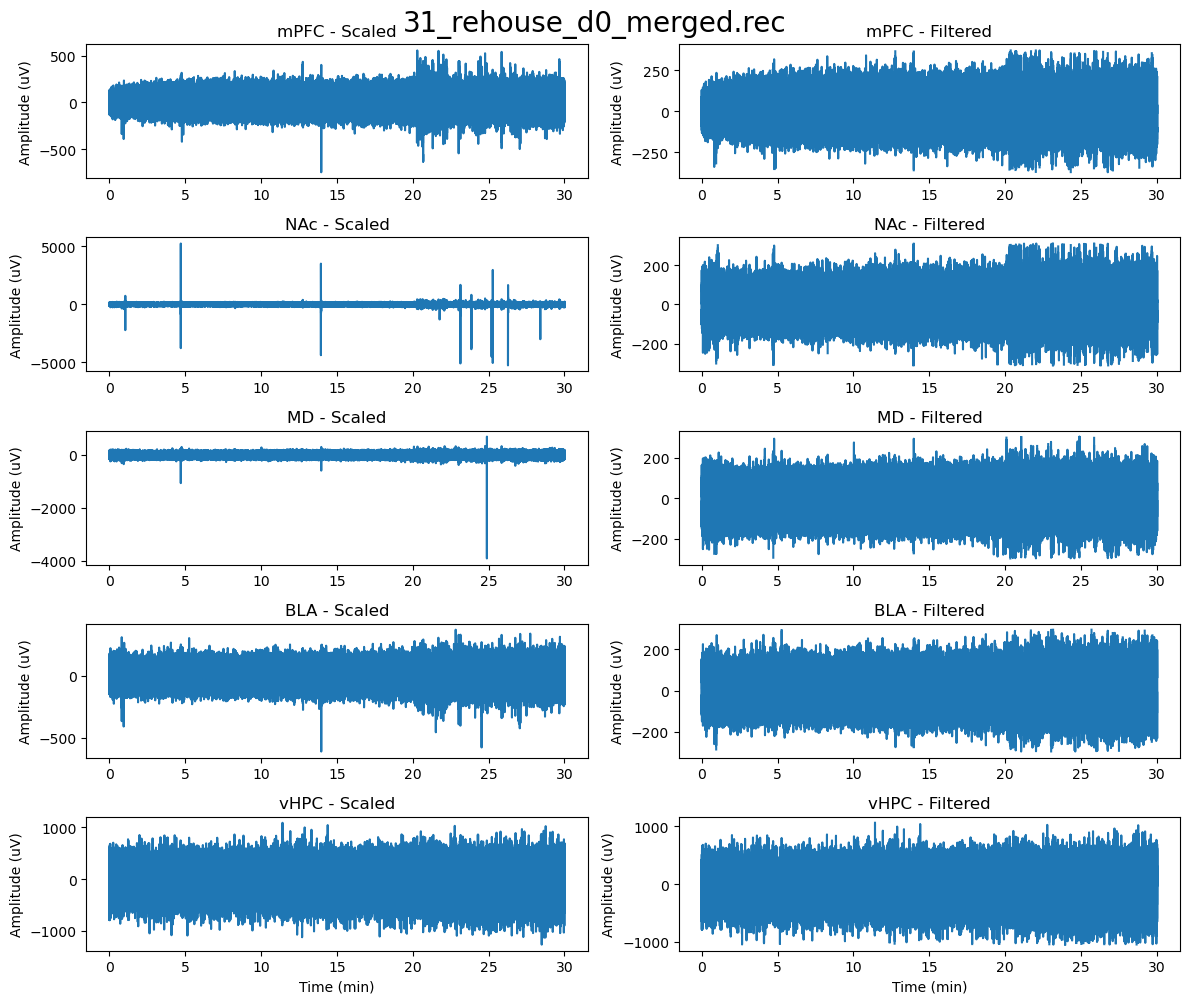

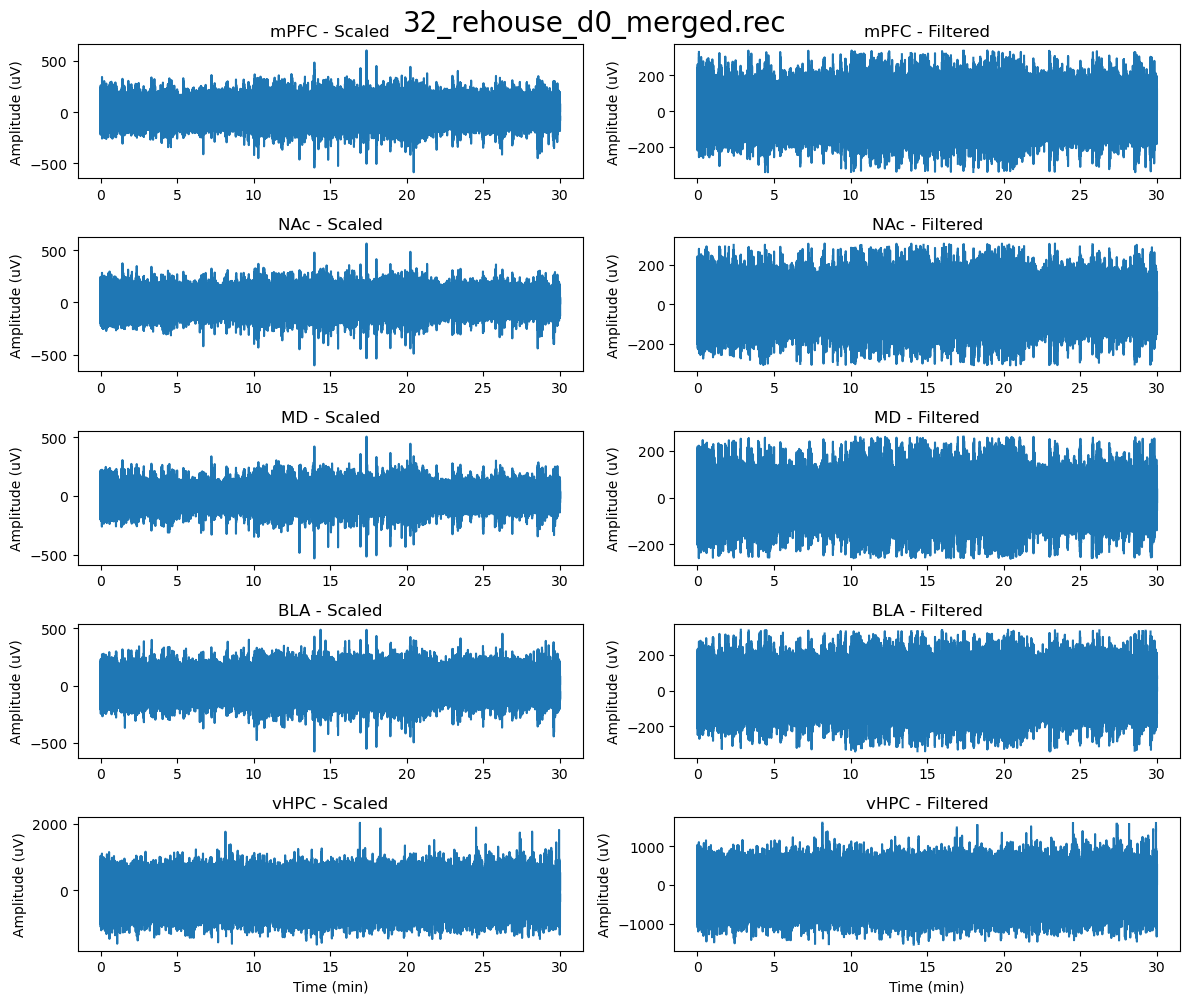

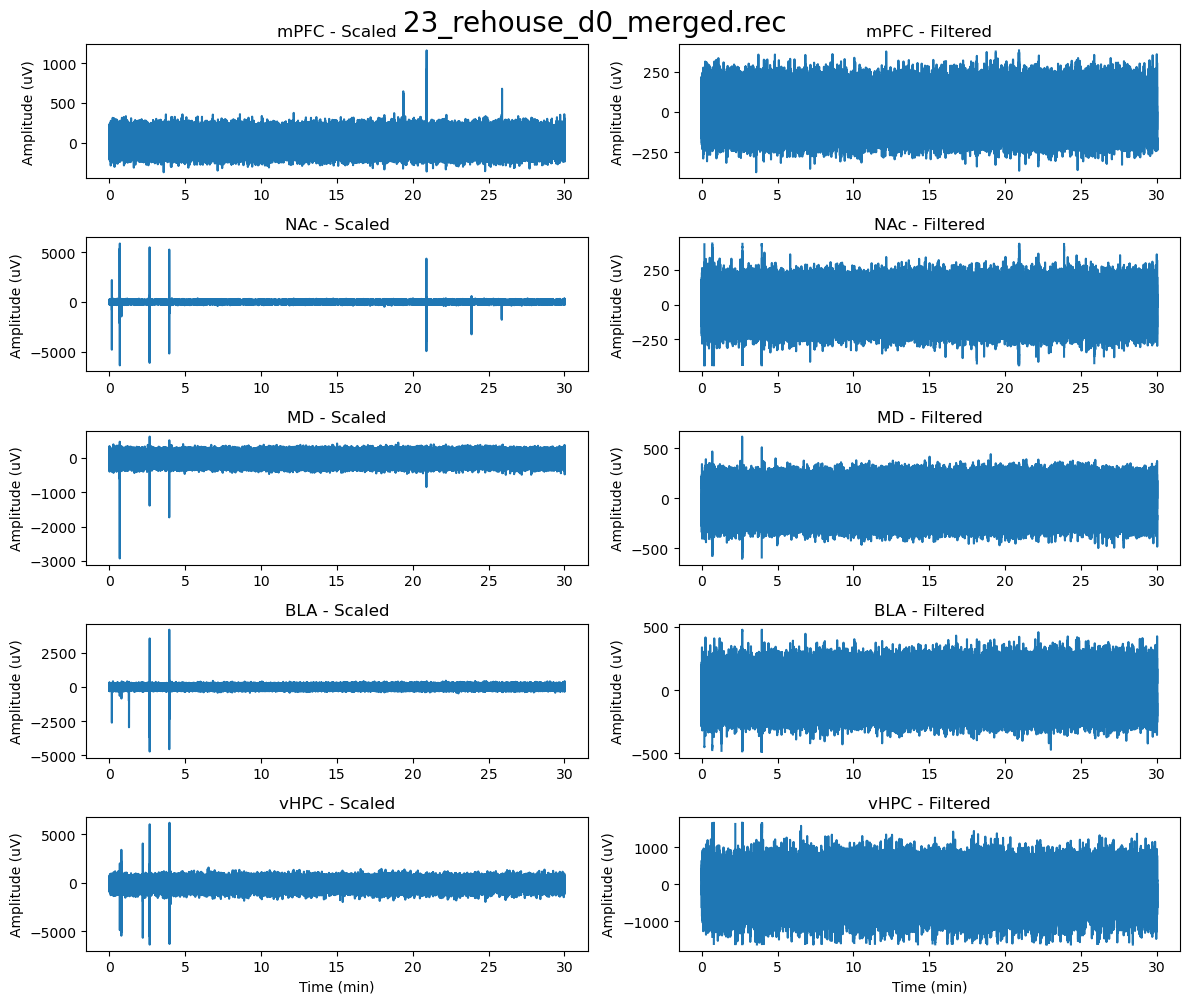

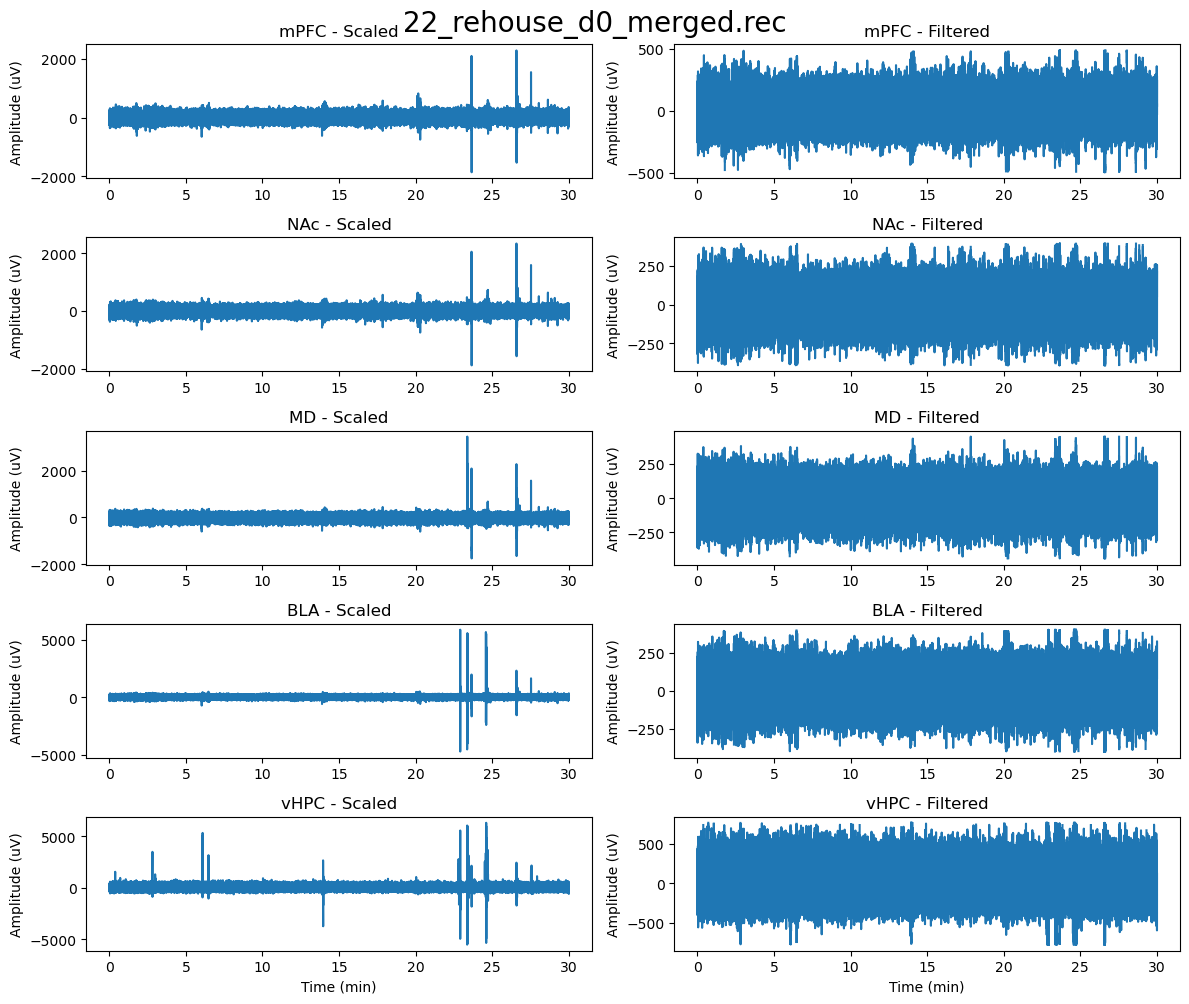

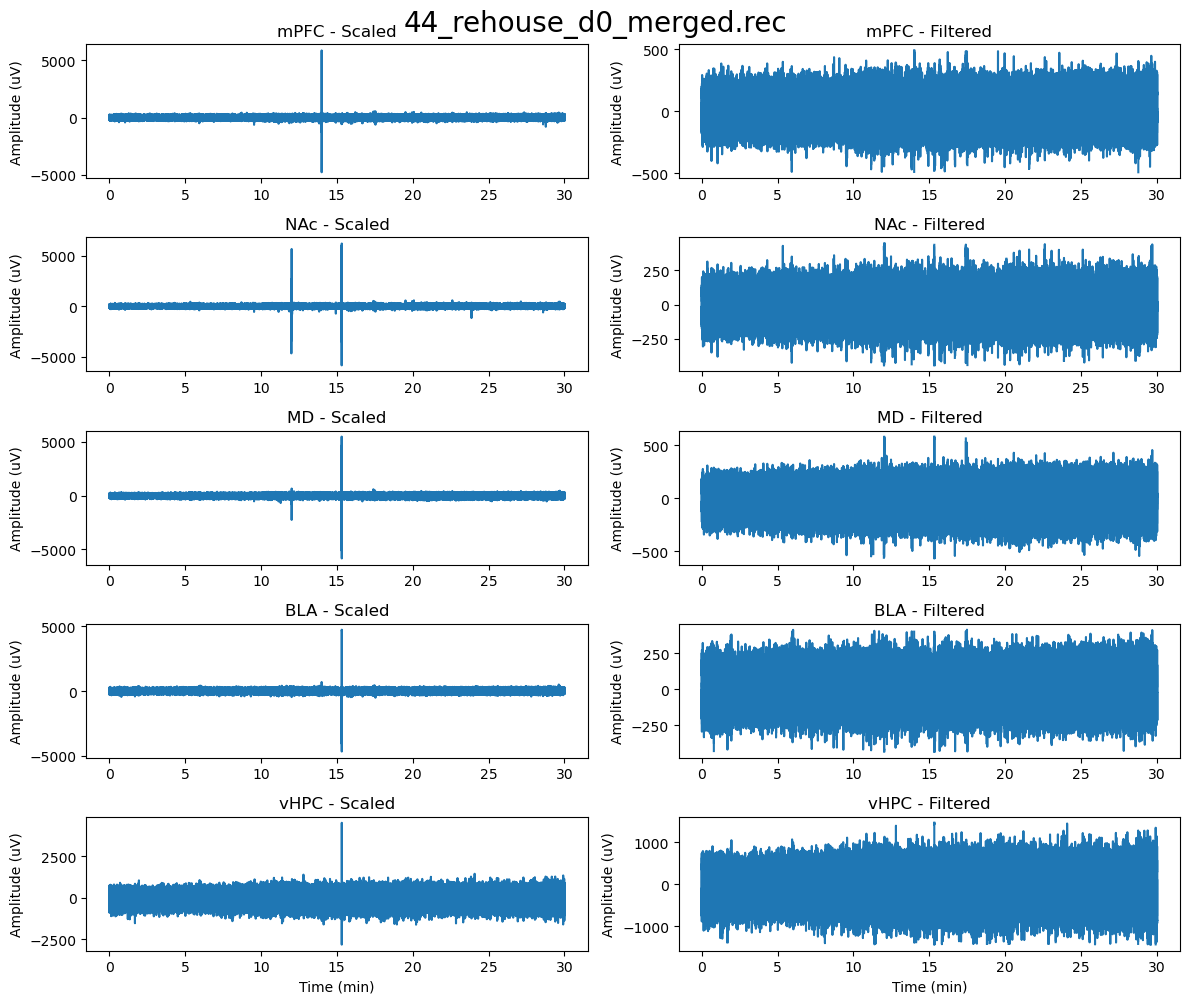

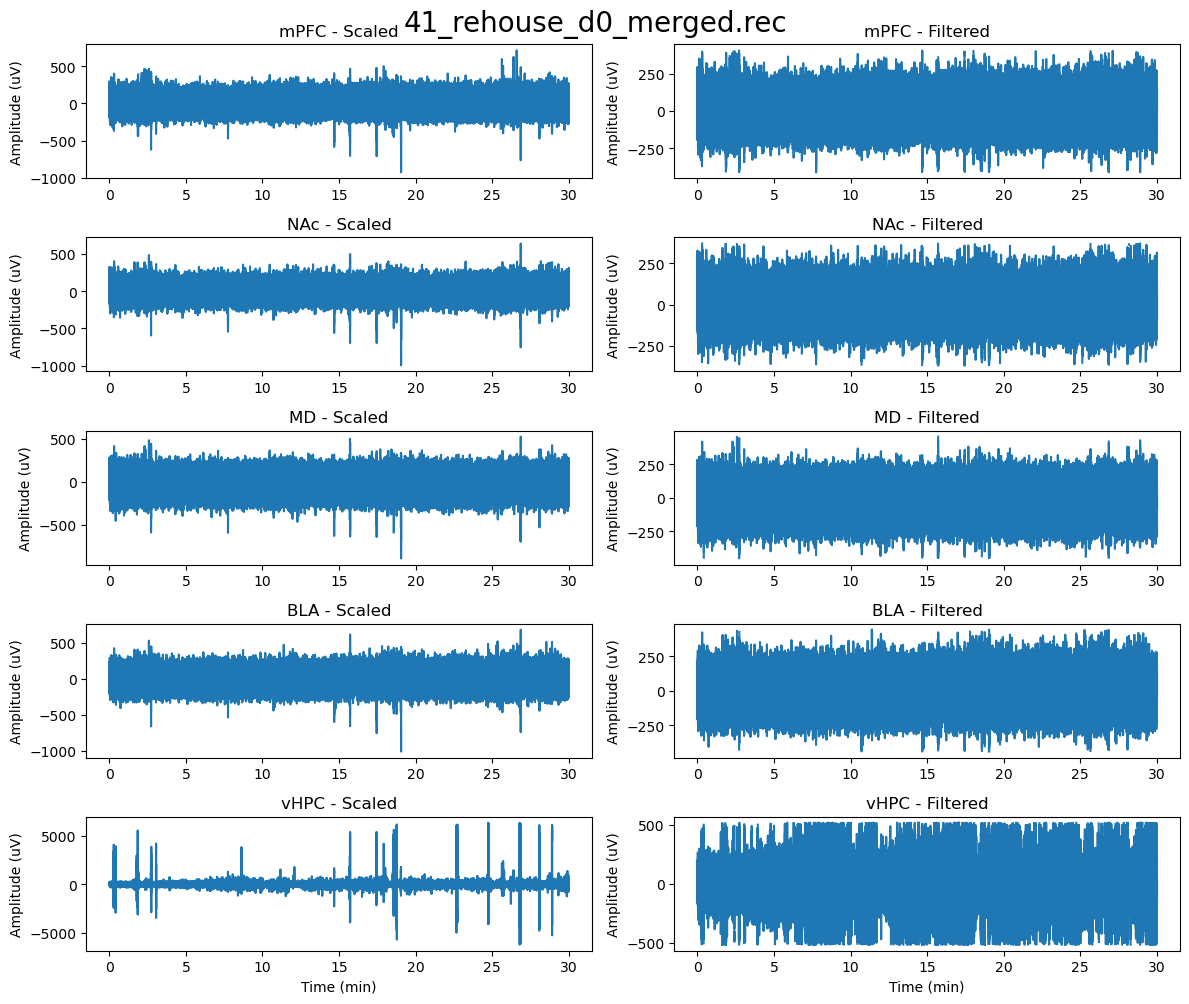

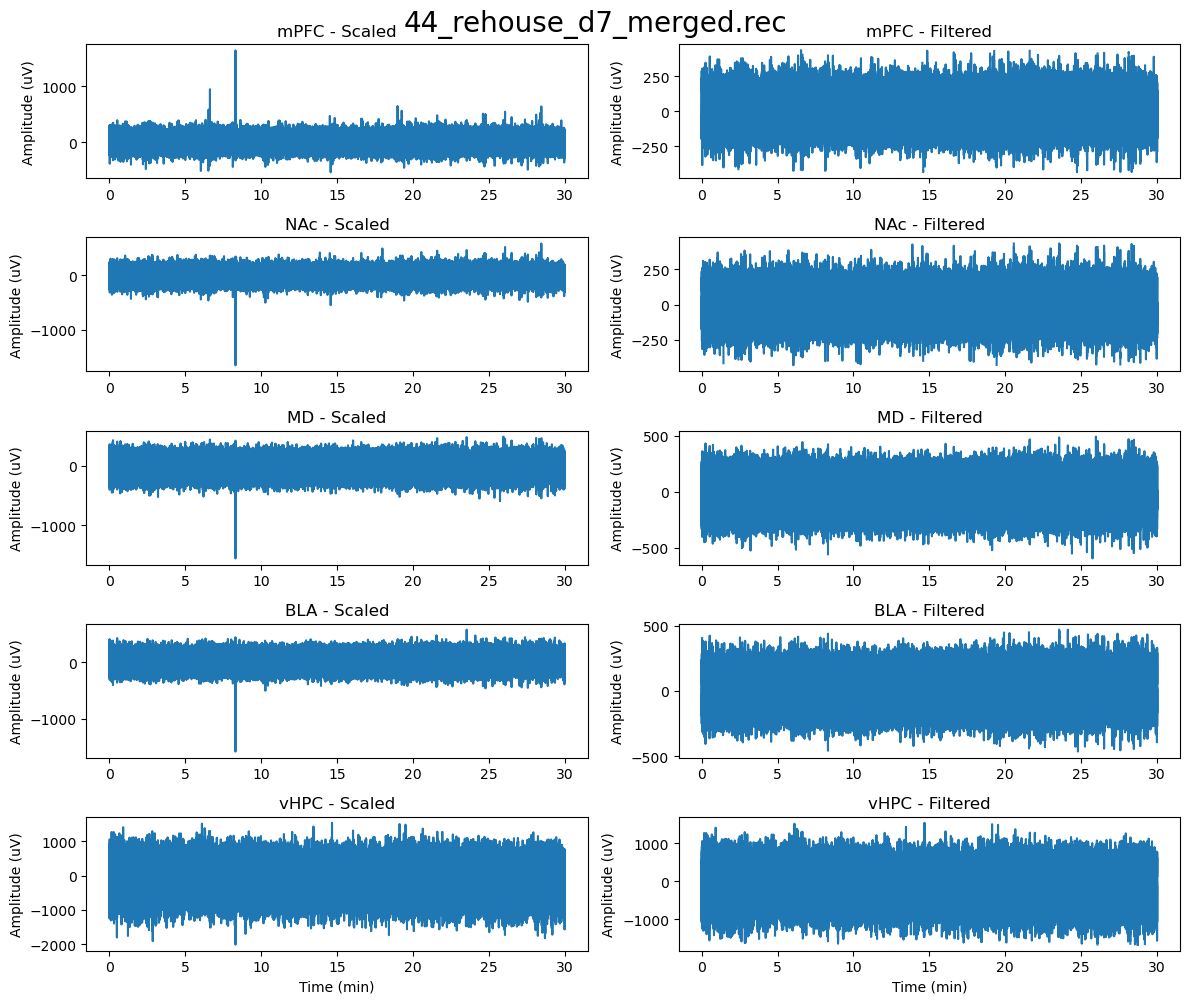

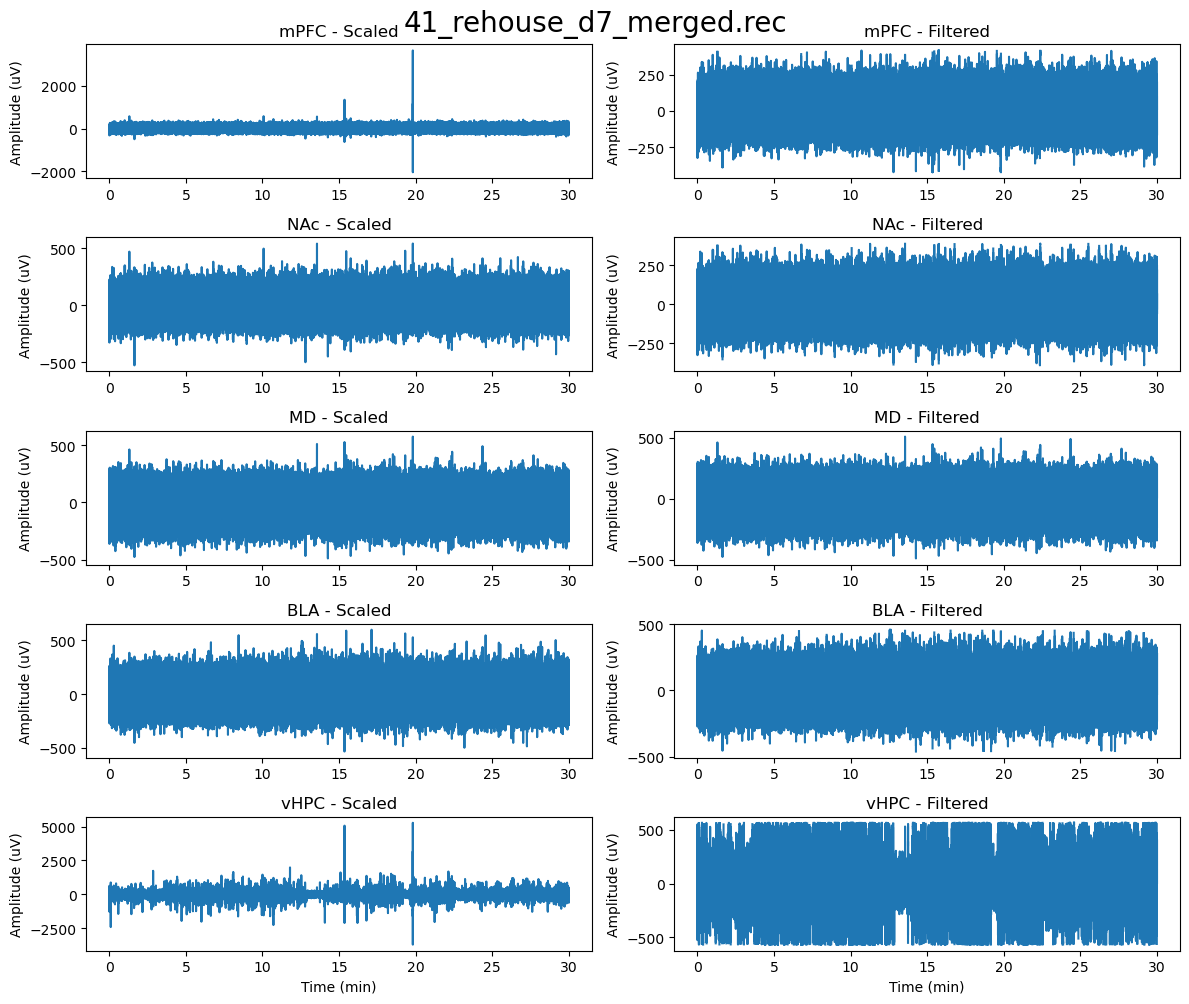

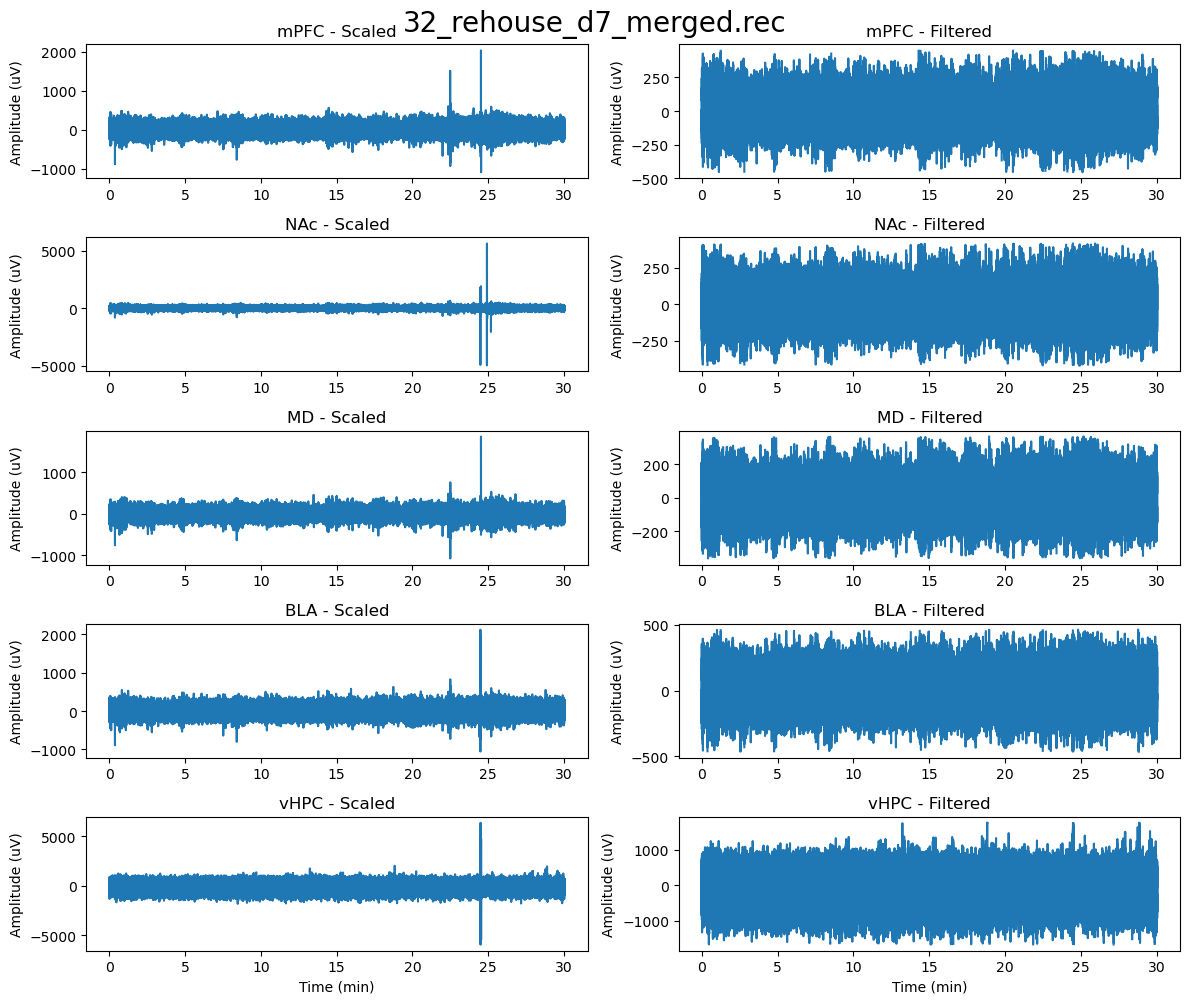

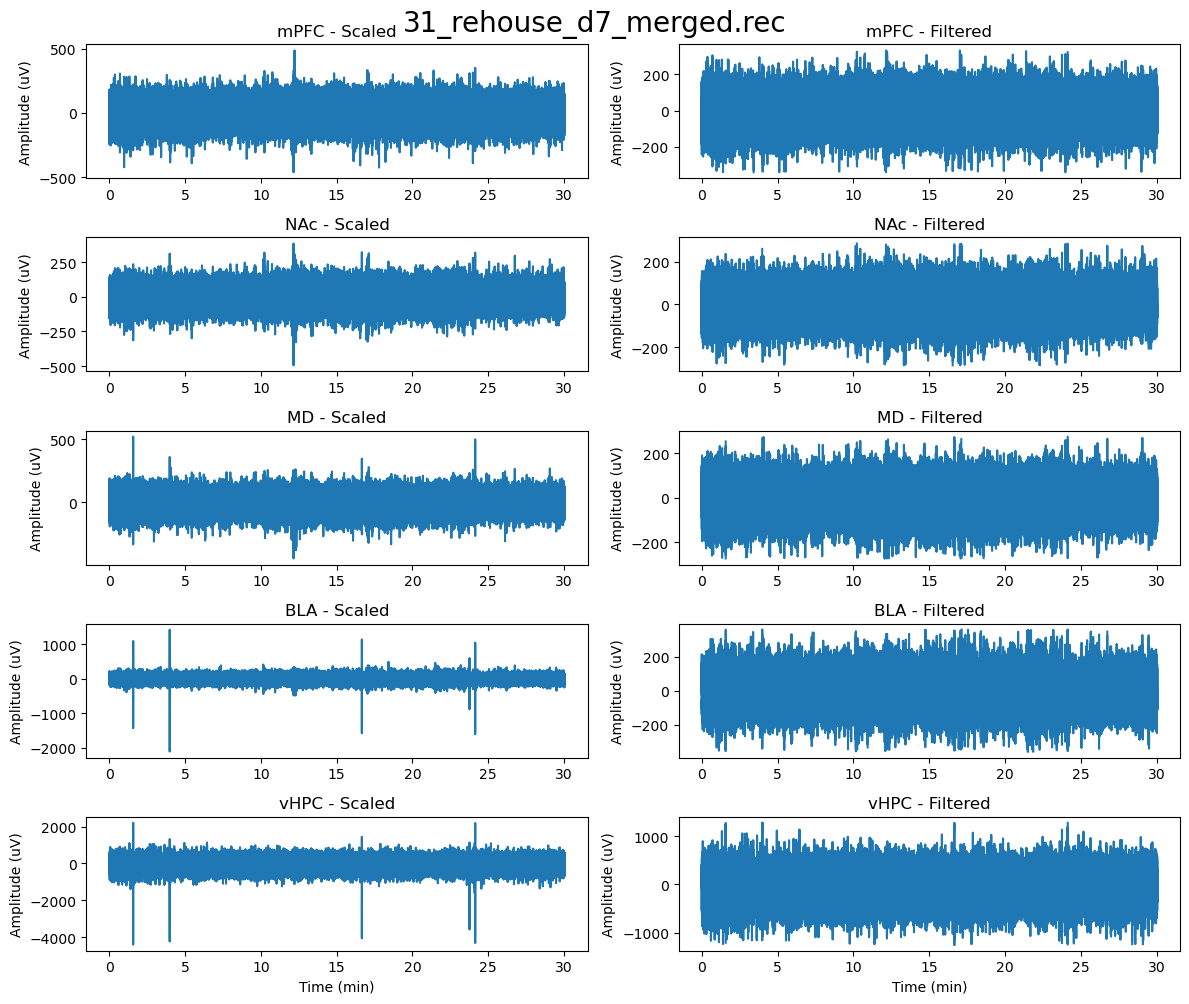

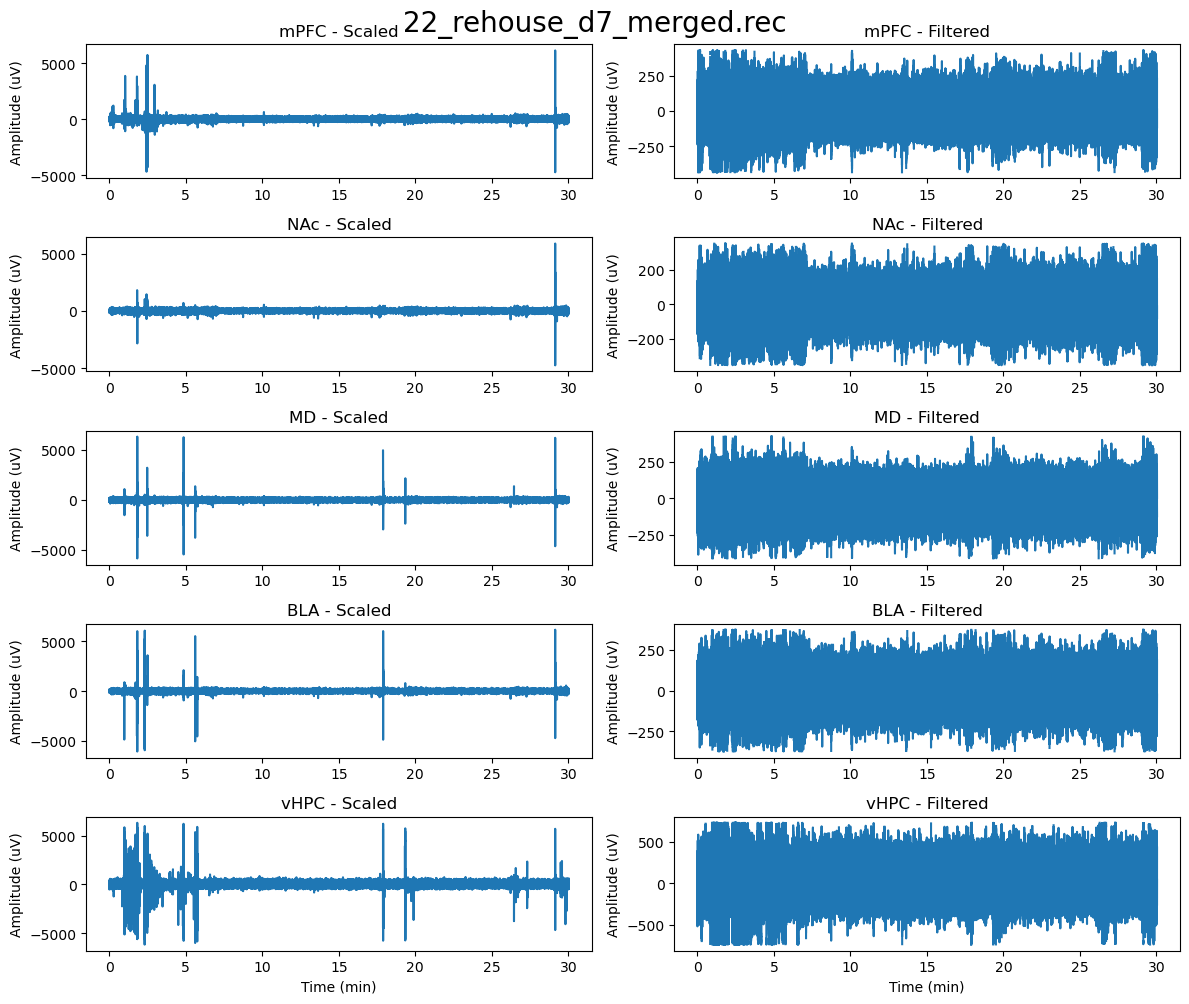

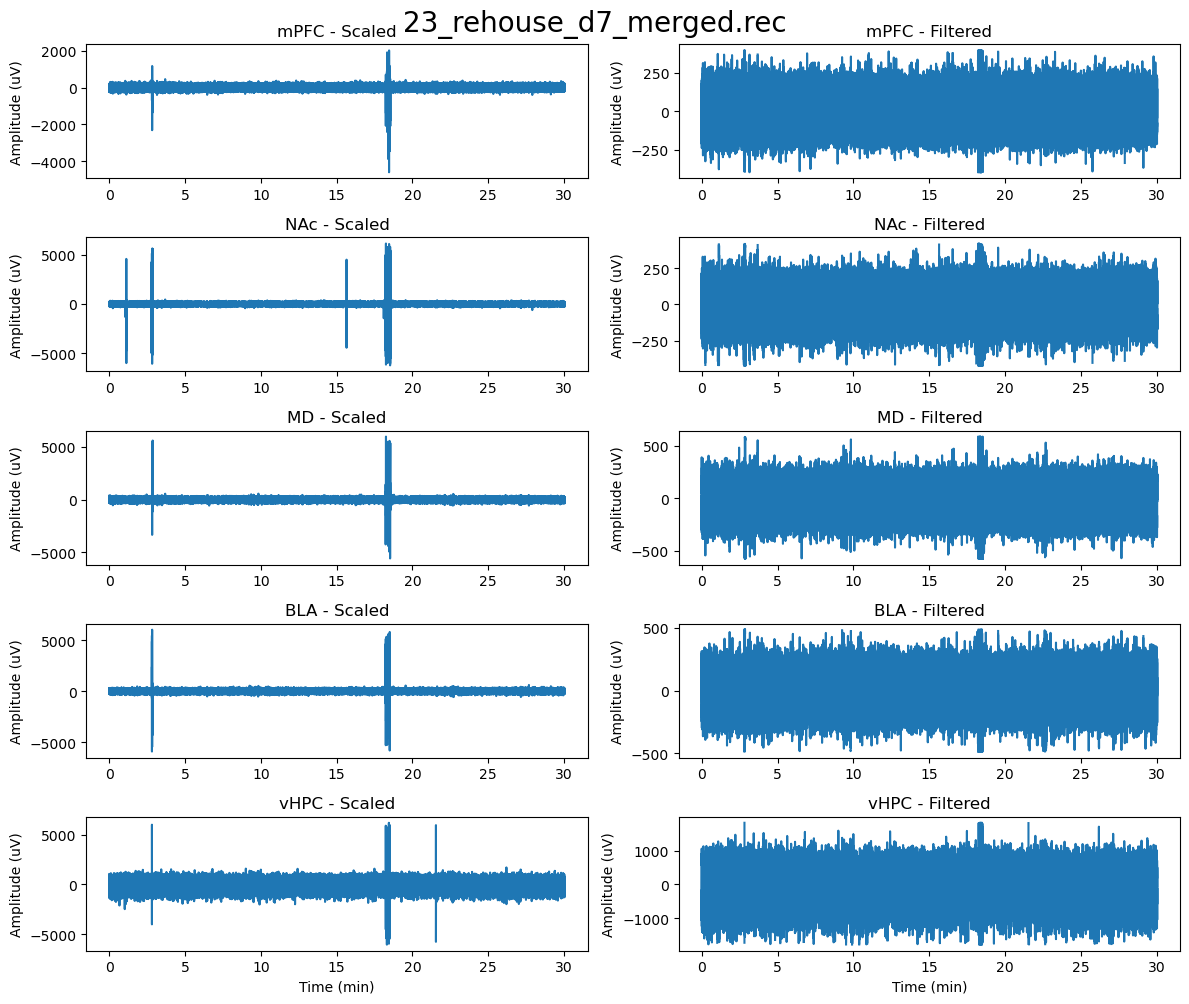

In [40]:
lfp_collection.diagnostic_plots(threshold=5)

In [41]:
# lfp_collection.diagnostic_plots_channel_finder()

### Saving collection to json+h5, saved to /home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/lfp_collections/aligned_lfpcollection_44_41

In [42]:
import json
import os

# Define where to save the collection
output_path = "/blue/npadillacoreano/sequioasmith/rehouse_code/lfp_collections"

# Add notes describing this dataset
notes = "Rehouse data - d0/d7 all subjects (22, 23, 31, 32, 41, 44) aligned LFPCollection"

# Create output directory if it does not exist
os.makedirs(output_path, exist_ok=True)

# Ensure the frequencies attribute is None so saving works properly
lfp_collection.frequencies = None

# Save the LFPCollection object
print(f"Saving LFPCollection to {output_path}...")
LFPCollection.save_to_json(
    lfp_collection,
    output_path=output_path,
    notes=notes,
    filename="aligned_lfpcollection_all_subj_d0_d7"
)
print("LFPCollection saved successfully to JSON and HDF5.")

Saving LFPCollection to /blue/npadillacoreano/sequioasmith/rehouse_code/lfp_collections...
LFPCollection saved successfully to JSON and HDF5.
